In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import (auc, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel
import shap

# DATA ACQUISITION

In [3]:
# dataset path definition
dataset_path = "../data/raw/capture20110815-2.csv"

In [4]:
print("--- Dataset loading... ---")

# load dataset
df = pd.read_csv(dataset_path)

print("--- Dataset loaded ---")

# number of rows and columns
print(f"Dimension of dataset: {df.shape}")

# dataset info
df.info()

--- Dataset loading... ---
--- Dataset loaded ---
Dimension of dataset: (129832, 15)
<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB


In [5]:
print("--- Dataset types ---")
print(df.dtypes)

print("--- Verify correct load ---")
df.head(5)

--- Dataset types ---
StartTime        str
Dur          float64
Proto            str
SrcAddr          str
Sport            str
Dir              str
DstAddr          str
Dport            str
State            str
sTos         float64
dTos         float64
TotPkts        int64
TotBytes       int64
SrcBytes       int64
Label            str
dtype: object
--- Verify correct load ---


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


# DATA TRASFORMATION

In [6]:
#target mapping
df['Target'] = (df['Label'].astype(str).str.contains('Botnet', case=False, regex=False)).astype(int)

# DATA EXPLORATION

Distribuition after binary mapping (Target):
Class 0 (Normal/Background): 128,931 (99.31%)
Class 1 (Botnet): 901 (0.69%)


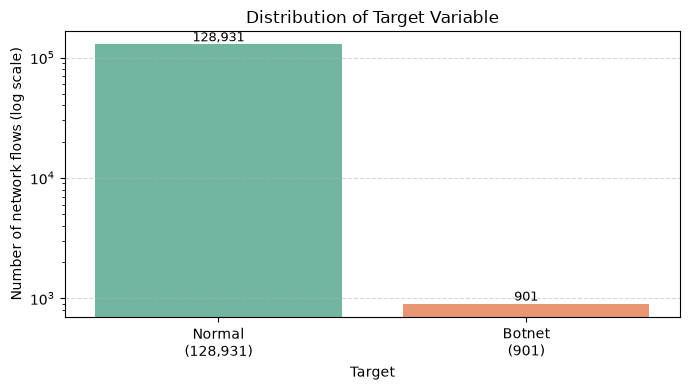

In [7]:
target_counts = df['Target'].value_counts()
target_props = df['Target'].value_counts(normalize=True) * 100

print ("Distribuition after binary mapping (Target):")
print(f"Class 0 (Normal/Background): {target_counts.get(0, 0):,} ({target_props.get(0, 0):.2f}%)")
print(f"Class 1 (Botnet): {target_counts.get(1, 0):,} ({target_props.get(1, 0):.2f}%)")

#visualization unbalanced dataset
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    x='Target', hue='Target', data=df, palette='Set2', legend=False
)

#logarithmic scale
ax.set_yscale('log')
plt.title('Distribution of Target Variable', fontsize=12)
plt.ylabel('Number of network flows (log scale)')
plt.xticks(
    [0, 1],
    [
        f"Normal\n({target_counts.get(0, 0):,})",
        f"Botnet\n({target_counts.get(1, 0):,})",
    ],
)

#numerical annotation on top of bars
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 0), #text offset
        textcoords='offset points',
        fontsize=9,
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

#set layout to avoid overlapping
plt.tight_layout()
plt.show()

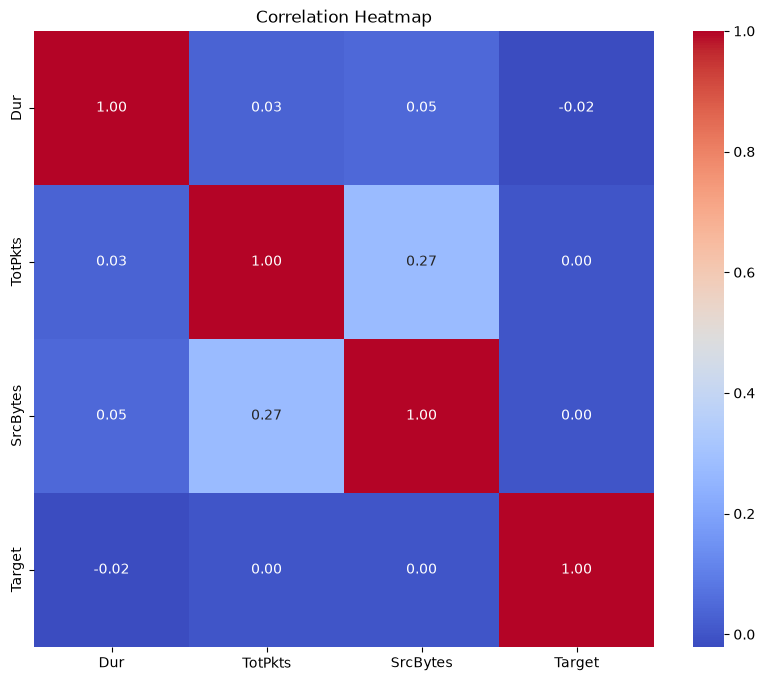


--- Comparative dscriptive statistics ---
Target                      0              1
Dur      median  7.190000e-04       1.592649
         mean    7.793546e+01       6.489200
         std     2.831898e+02      43.092420
         max     1.805828e+03    1139.728638
TotPkts  median  2.000000e+00       6.000000
         mean    3.451280e+01      34.819090
         std     2.502953e+03      78.786008
         max     6.945530e+05     678.000000
SrcBytes median  8.100000e+01     186.000000
         mean    5.040658e+03   10965.527192
         std     5.197573e+05   49864.479033
         max     1.365468e+08  600198.000000


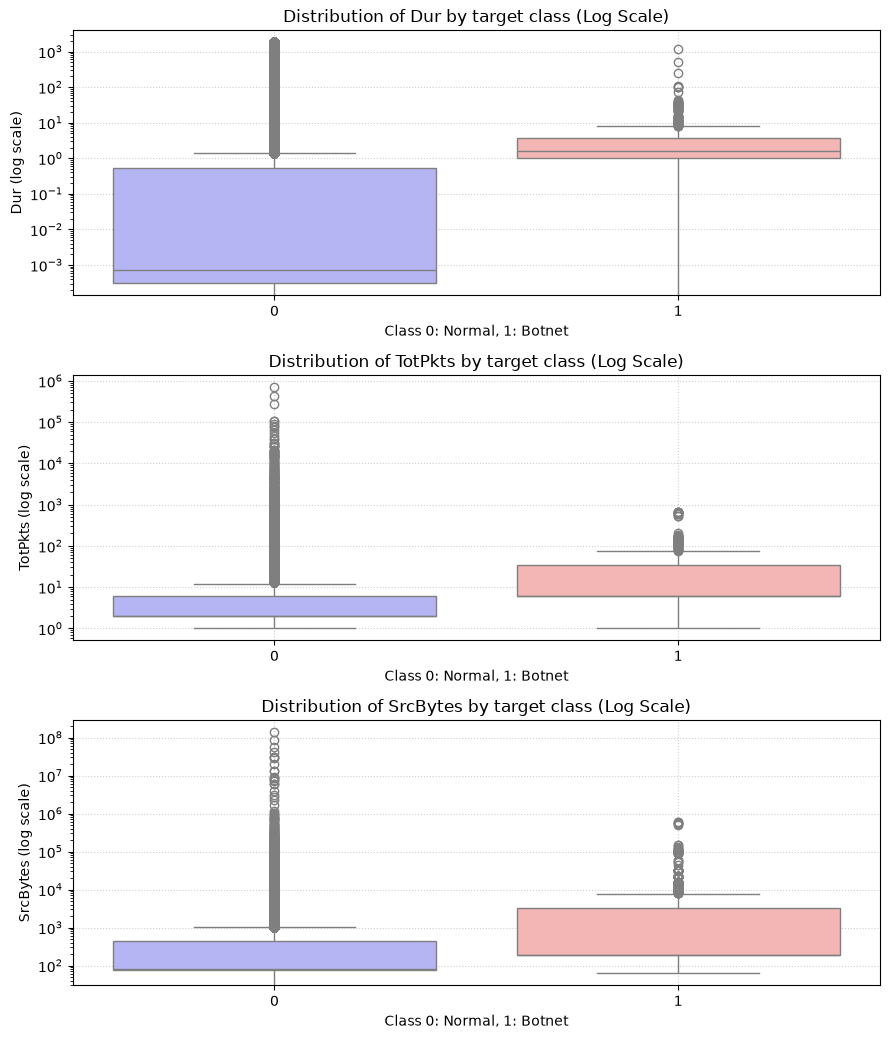

In [8]:
numerical_features = ['Dur', 'TotPkts', 'SrcBytes']

#numerical features conversion, coerce to Nan if conversion fails
for col in numerical_features:
  df[col] = pd.to_numeric(df[col], errors='coerce')

#heatmap correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[['Dur', 'TotPkts', 'SrcBytes', 'Target']].corr(), annot=True, cmap='coolwarm', fmt='.2f',)
plt.title('Correlation Heatmap')
plt.show()

if numerical_features:
  #descriptive statistics confrontation by target class
  print("\n--- Comparative dscriptive statistics ---")
  comparative_stats = df.groupby('Target')[numerical_features].agg(['median', 'mean', 'std', 'max'])
  print(comparative_stats.T)

  #numerical features distribution visualization by target
  num_cols = len(numerical_features)

  #plotting boxplots
  fig, axes = plt.subplots(num_cols, 1, figsize=(9, 3.5 * num_cols))

  for ax, col in zip(axes, numerical_features):
    #boxplot su scala logaritmica per evidenziare la differenza di distribuzione
    sns.boxplot(data=df, x='Target', y=col, hue='Target', palette='bwr', ax=ax,legend=False)
    ax.set_yscale('log')
    ax.set_title(f'Distribution of {col} by target class (Log Scale)')
    ax.set_xlabel('Class 0: Normal, 1: Botnet')
    ax.set_ylabel(f'{col} (log scale)')
    ax.grid(True, linestyle=':', alpha=0.6)

  #set layout to avoid overlapping
  plt.tight_layout()
  plt.show()


--- Categorical features check ---
Feature 'Proto': 11 unique values
Feature 'State': 155 unique values
Feature 'Dport': 12013 unique values
Feature 'Dport_cat': 4 unique values


<Figure size 640x480 with 0 Axes>

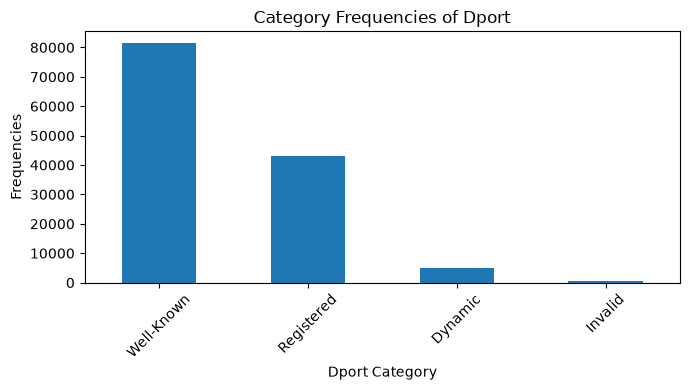

In [9]:
#decimal conversion Dport
for col in ['Dport']:
  df[col] = df[col].replace(r'^\s*$', np.nan, regex=True) #replace empty strings with NaN

  df[col] = df[col].apply(
    lambda x: (int(str(x), 16)
    if pd.notna(x) and str(x).strip().lower().startswith('0x')
    else x
    )
  )

  df[col] = pd.to_numeric(df[col], errors='coerce') #convert to numeric, coerce errors to NaN
  df[col] = df[col].fillna(-1).astype(int).astype(str) #replace NaN with -1, conversion to str

def categorize_port(port):
    """Categorizza le porte secondo lo standard IANA."""
    try:
        # Gestione di valori esadecimali o formati stringa
        if isinstance(port, str) and port.startswith('0x'):
            p = int(port, 16)
        else:
            p = float(port)
            
        if pd.isna(p):
            return 'Missing'
            
        p = int(p)
        if 0 <= p <= 1023:
            return 'Well-Known'
        elif 1024 <= p <= 49151:
            return 'Registered'
        elif 49152 <= p <= 65535:
            return 'Dynamic'
        else:
            return 'Invalid'
    except (ValueError, TypeError):
        return 'Invalid'

if 'Dport' in df.columns:
  df['Dport_cat'] = df['Dport'].apply(categorize_port)

# Pulizia delle stringhe
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

categorical_features = ['Proto', 'State', 'Dport', 'Dport_cat']
if categorical_features:
  print("\n--- Categorical features check ---")
  for col in categorical_features:
    number_unique = df[col].nunique()
    print(f"Feature '{col}': {number_unique} unique values")

Dport_category = df['Dport_cat'].value_counts()

#set layout to avoid overlapping
plt.tight_layout()
plt.show()

#barplot Dport frequency
plt.figure(figsize=(7, 4))
Dport_category.plot(kind="bar")

plt.xlabel("Dport Category")
plt.ylabel("Frequencies")
plt.title("Category Frequencies of Dport")
plt.xticks(rotation=45)

#set layout to avoid overlapping
plt.tight_layout()
plt.show()

# DATA PREPROCESSING

In [10]:
# extraction temporal features
if 'StartTime' in df.columns:
    #conversion of StartTime to datetime, coerce errors to NaT
    df['StartTime'] = pd.to_datetime(df['StartTime'], errors='coerce')
    df['Hour'] = df['StartTime'].dt.hour
    df['DayOfWeek'] = df['StartTime'].dt.dayofweek
    df = df.drop(columns=['StartTime'])

#remove empty extra spaces
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

#remove columns probably data leakage
cols_to_drop = ['Label', 'Target', 'Dir', 'SrcAddr', 'DstAddr', 'Sport']

#definition of X: features, y: target
X = df.drop(columns=cols_to_drop)
y = df['Target']

categorical_features_raw = ['Proto', 'State', 'Dport']
categorical_features_cat = ['Proto', 'State', 'Dport_cat']

print(f"Selected numerical features: {numerical_features}")
print(f"Selected categorical features (raw): {categorical_features_raw}")
print(f"Selected categorical features (IANA): {categorical_features_cat}")

#pipeline preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)) #activate sparse matrix for memory efficiency
])

#union transformers in a preprocessor
preprocessor_raw = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features_raw)
    ],
    remainder='drop' #remove columns not specified
)

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features_cat)
    ],
    remainder='drop' #remove columns not specified
)

print("Preprocessing pipeline created successfully.")

Selected numerical features: ['Dur', 'TotPkts', 'SrcBytes']
Selected categorical features (raw): ['Proto', 'State', 'Dport']
Selected categorical features (IANA): ['Proto', 'State', 'Dport_cat']
Preprocessing pipeline created successfully.


# DATA MINING

In [11]:
#RANDOM FOREST cost sensitive learning
rf_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', #major weight to minority class
        max_depth=None, #limit depth to avoid overfitting
        random_state=42, 
        n_jobs=-1
    ))
])

rf_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', #major weight to minority class
        max_depth=None, #limit depth to avoid overfitting
        random_state=42, 
        n_jobs=-1
    ))
])

#LOGISTIC REGRESSION
lr_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, #maximum iterations for convergence
        random_state=42
    ))
])

lr_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, #maximum iterations for convergence
        random_state=42
    ))
])

#DECISION TREE
dt_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', #unbalanced compensation
        max_depth=None, #limit depth to avoid overfitting
        random_state=42
    ))
])

dt_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', #unbalanced compensation
        max_depth=None, #limit depth to avoid overfitting
        random_state=42
    ))
])

#XGBOOST
scale_weight = (y == 0).sum() / (y == 1).sum()

xgb_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_weight, #unbalanced compensation
        random_state=42,
        eval_metric='logloss' #error valuation metric during training
    ))
])

xgb_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_weight, #unbalanced compensation
        random_state=42,
        eval_metric='logloss' #error valuation metric during training
    ))
])

print("Pipelines created successfully.")

Pipelines created successfully.


# MODEL EVALUATION

Evaluation in progress for Random Forest...
Evaluation in progress for Logistic Regression...
Evaluation in progress for Decision Tree...

================ COMPARATIVE PERFORMANCE TABLE ================
              Model Precision (Botnet) Recall (Botnet) F1-Score (Botnet)          PR-AUC
      Random Forest    0.8993 ± 0.0192 0.8868 ± 0.0309   0.8926 ± 0.0156 0.9196 ± 0.0275
      Decision Tree    0.8699 ± 0.0234 0.8646 ± 0.0423   0.8666 ± 0.0248 0.8207 ± 0.0406
Logistic Regression    0.0539 ± 0.0021 0.9368 ± 0.0186   0.1020 ± 0.0039 0.7315 ± 0.0834



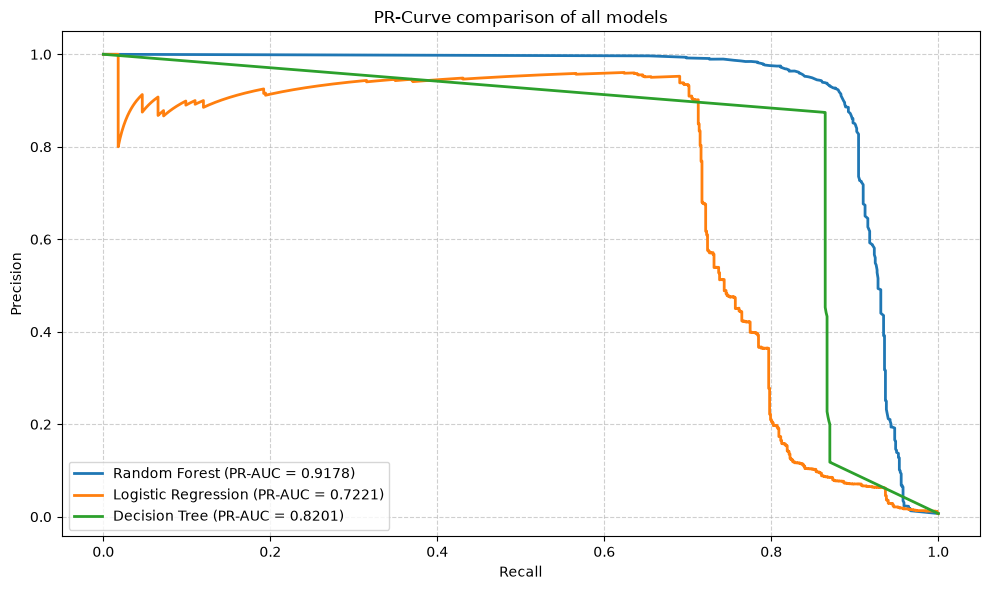

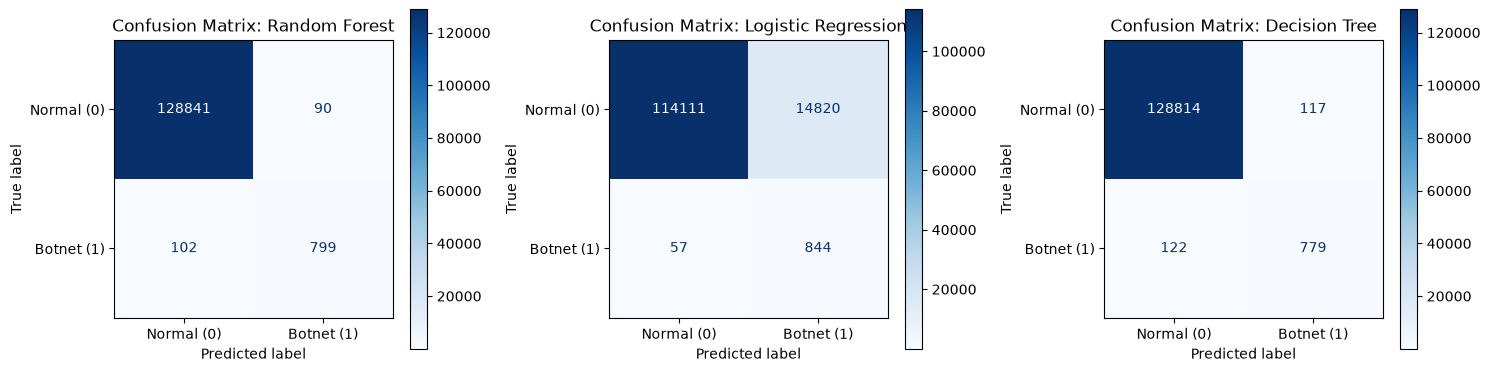

In [12]:
models = {
    'Random Forest': rf_pipeline_raw,
    'Logistic Regression': lr_pipeline_raw,
    'Decision Tree': dt_pipeline_raw,
}

#10-fold stratified cross-validation, shuffle=True to randomize data order
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_list = []
#dict to save predictions for confusion matrix
y_predicted_dict = {}

#salvo metriche per ogni fold per ogni modello
fold_metrics_dict = {}

plt.figure(figsize=(10, 6))

for name, pipeline in models.items():
  print(f"Evaluation in progress for {name}...")

  y_predicted = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
  #botnet probability
  y_probability = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

  #save predictions for confusion matrix
  y_predicted_dict[name] = y_predicted

  #metric calculation for each fold
  fold_precision, fold_recalls, fold_f1s, fold_pr_auc= [], [], [], []

  #training set already calculated
  for _, test_idx in skf.split(X, y):
    y_test_fold = y.iloc[test_idx]
    #predictions and probabilities for the current fold
    y_predicted_fold = y_predicted[test_idx]
    y_probability_fold = y_probability[test_idx]

    fold_precision.append(precision_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
    fold_recalls.append(recall_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
    fold_f1s.append(f1_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))

    #curve computation based on probabilities for the current fold
    precision_curve_fold, recall_curve_fold, _ = precision_recall_curve(y_test_fold, y_probability_fold)
    fold_pr_auc.append(auc(recall_curve_fold, precision_curve_fold))

  # save fold metrics for the current model
  fold_metrics_dict[name] = {
    'F1-Score (Botnet)': fold_f1s,
    'PR-AUC': fold_pr_auc
  }

  precision_curve, recall_curve, threshold = precision_recall_curve(y, y_probability)
  pr_auc = auc(recall_curve, precision_curve)

  results_list.append({
    'Model': name,
    'Precision (Botnet)': f"{np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}",
    'Recall (Botnet)': f"{np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}",
    'F1-Score (Botnet)': f"{np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}",
    'PR-AUC': f"{np.mean(fold_pr_auc):.4f} ± {np.std(fold_pr_auc):.4f}",
    'PR-AUC_sort': np.mean(fold_pr_auc),
  })

  #PR-Curve
  plt.plot(
      recall_curve,
      precision_curve,
      lw=2,
      label=f'{name} (PR-AUC = {pr_auc:.4f})',
  )

#comparative table
df_results = pd.DataFrame(results_list).sort_values(by='PR-AUC_sort', ascending=False).drop(columns=['PR-AUC_sort'])

print('\n================ COMPARATIVE PERFORMANCE TABLE ================')
print(df_results.to_string(index=False))
print('=======================================================================\n')

#PR-Curve output
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-Curve comparison of all models')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
#set layout to avoid overlapping
plt.tight_layout()
plt.show()

#output confusion matrix
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
axes = axes.flatten()

for i, (name, y_predicted) in enumerate (y_predicted_dict.items()):
  cm = confusion_matrix(y, y_predicted)
  display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Botnet (1)'])
  display.plot(ax=axes[i], cmap='Blues', values_format='d')
  axes[i].set_title(f'Confusion Matrix: {name}')

#set layout to avoid overlapping
plt.tight_layout()
plt.show()

Grouped Bar Plot

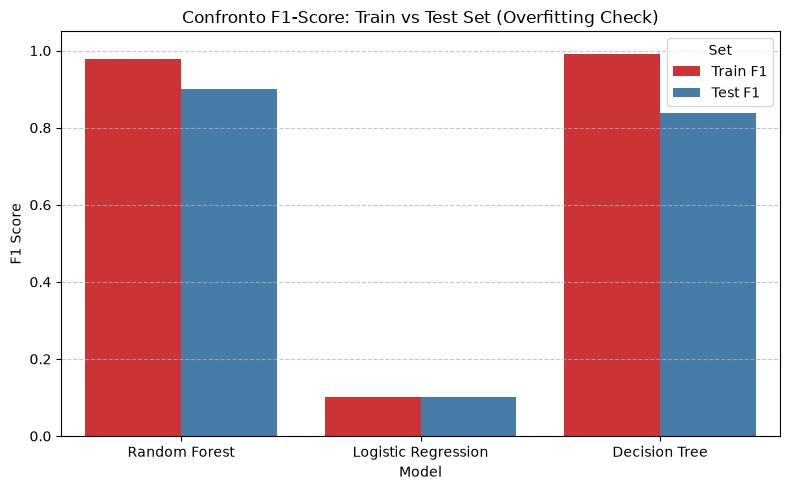

In [13]:
# 1. Divisione Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Calcolo F1-Score su Train e Test Set
results = []
for name, pipeline in models.items():
  pipeline.fit(X_train, y_train)

  y_train_pred = pipeline.predict(X_train)
  y_test_pred = pipeline.predict(X_test)

  results.append({
      'Model': name,
      'Train F1': f1_score(y_train, y_train_pred, pos_label=1),
      'Test F1': f1_score(y_test, y_test_pred, pos_label=1),
  })

df_results = pd.DataFrame(results)

# 3. Trasformazione e Grafico
df_melted = df_results.melt(
    id_vars=['Model'],
    value_vars=['Train F1', 'Test F1'],
    var_name='Set',
    value_name='F1 Score',
)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='F1 Score', hue='Set', data=df_melted, palette='Set1')
plt.title('Confronto F1-Score: Train vs Test Set (Overfitting Check)')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
print('\n================ STATISTICAL SIGNIFICANCE (PAIRED T-TEST) ================')

model1 = 'Random Forest' 
model2 = 'Decision Tree'             

metric_to_test = 'F1-Score (Botnet)'

m1_scores = fold_metrics_dict[model1][metric_to_test]
m2_scores = fold_metrics_dict[model2][metric_to_test]



t_stat, p_val = ttest_rel(m1_scores, m2_scores)

print(f"Comparing: {model1} vs {model2}")
print(f"Metric Evaluated: {metric_to_test}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print(f"Conclusion: The performance difference is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print(f"Conclusion: The performance difference is NOT statistically significant (p >= 0.05).")
print('==========================================================================\n')


================ STATISTICAL SIGNIFICANCE (PAIRED T-TEST) ================
Comparing: Random Forest vs Decision Tree
Metric Evaluated: F1-Score (Botnet)
T-statistic: 3.9692
P-value: 0.0033
Conclusion: The performance difference is STATISTICALLY SIGNIFICANT (p < 0.05).



Dimensione del campione per SHAP: (500, 12182)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

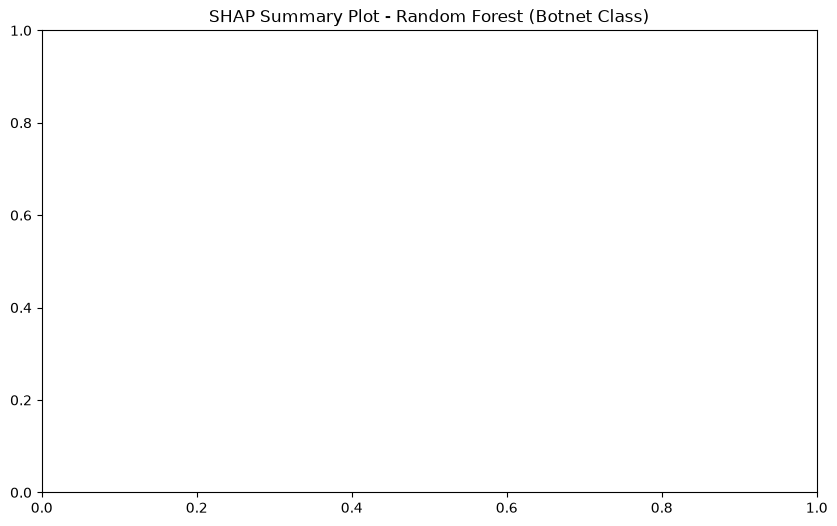

In [17]:
import shap
import scipy.sparse
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample

# 1. Estraiamo pre-processore e classificatore dalla pipeline
preprocessor = rf_pipeline_raw.named_steps['preprocessor']
rf_model = rf_pipeline_raw.named_steps['classifier']

# 2. Trasformiamo i dati (restituisce una matrice sparsa)
X_transformed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# 3. CAMPIONIAMO PRIMA (estraiamo solo 500 righe dalla matrice sparsa)
X_sampled_sparse = resample(X_transformed, n_samples=500, random_state=42)

# 4. CONVERTIAMO DOPO (convertiamo in array denso solo le 500 righe)
if scipy.sparse.issparse(X_sampled_sparse):
    X_sampled_dense = X_sampled_sparse.toarray()
else:
    X_sampled_dense = np.array(X_sampled_sparse)
    
X_sampled_dense = X_sampled_dense.astype(float)

print(f"Dimensione del campione per SHAP: {X_sampled_dense.shape}")

# 5. Creiamo il TreeExplainer 
# Aggiungiamo check_additivity=False per evitare ulteriori crash su foreste molto complesse
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sampled_dense, check_additivity=False)

# 6. Summary Plot per la classe 1 (Botnet)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - Random Forest (Botnet Class)")
shap.summary_plot(shap_values[1], X_sampled_dense, feature_names=feature_names)
plt.show()

Evaluation in progress for Random Forest (Categorized)...
Evaluation in progress for Logistic Regression (Categorized)...
Evaluation in progress for Decision Tree (Categorized)...

================ COMPARATIVE PERFORMANCE TABLE ================
                            Model Precision (Botnet) Recall (Botnet) F1-Score (Botnet)          PR-AUC
      Random Forest (Categorized)    0.7605 ± 0.0468 0.8057 ± 0.0446   0.7816 ± 0.0375 0.7996 ± 0.0364
      Decision Tree (Categorized)    0.7728 ± 0.0301 0.7469 ± 0.0461   0.7583 ± 0.0224 0.6818 ± 0.0366
Logistic Regression (Categorized)    0.0444 ± 0.0013 0.9256 ± 0.0217   0.0848 ± 0.0024 0.2649 ± 0.0260



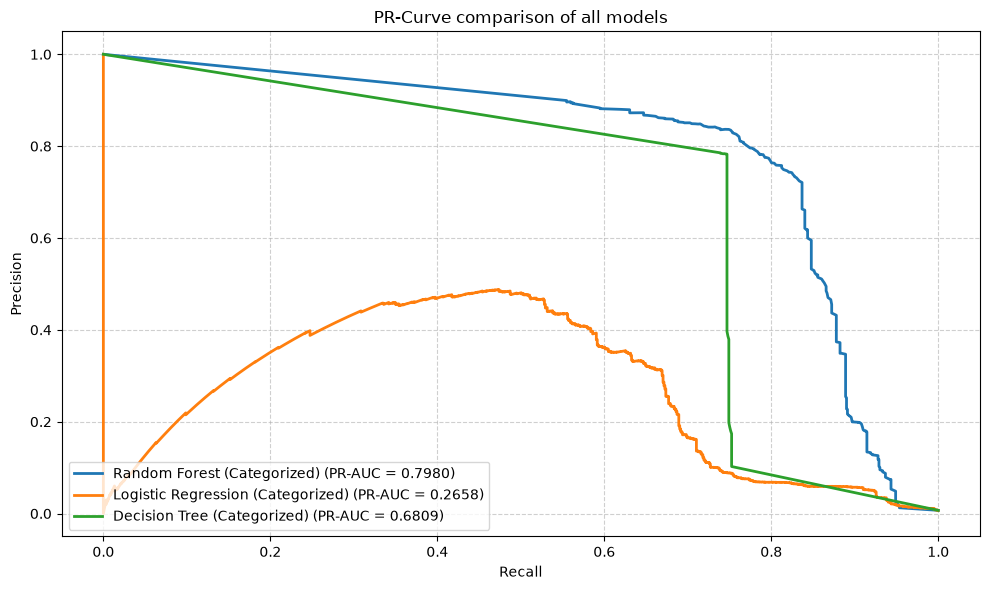

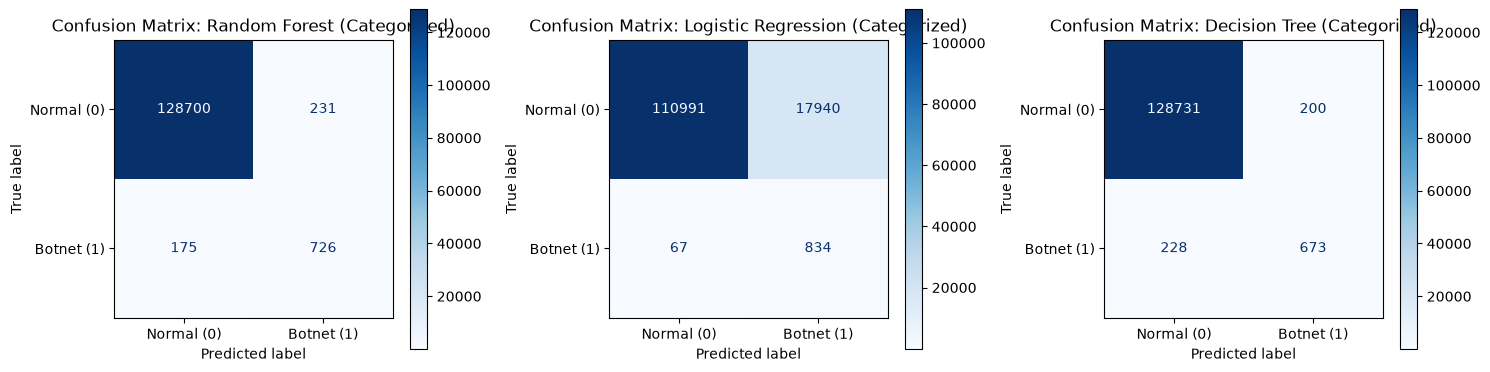

In [ ]:
models_categorized = {
    'Random Forest (Categorized)': rf_pipeline_cat,
    'Logistic Regression (Categorized)': lr_pipeline_cat,
    'Decision Tree (Categorized)': dt_pipeline_cat,
}

#10-fold stratified cross-validation, shuffle=True to randomize data order
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_list = []
#dict to save predictions for confusion matrix
y_predicted_dict = {}

#salvo metriche per ogni fold per ogni modello
fold_metrics_dict = {}

plt.figure(figsize=(10, 6))

for name, pipeline in models_categorized.items():
  print(f"Evaluation in progress for {name}...")

  y_predicted = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
  #botnet probability
  y_probability = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

  #save predictions for confusion matrix
  y_predicted_dict[name] = y_predicted

  #metric calculation for each fold
  fold_precision, fold_recalls, fold_f1s, fold_pr_auc= [], [], [], []

  #training set already calculated
  for _, test_idx in skf.split(X, y):
    y_test_fold = y.iloc[test_idx]
    #predictions and probabilities for the current fold
    y_predicted_fold = y_predicted[test_idx]
    y_probability_fold = y_probability[test_idx]

    fold_precision.append(precision_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
    fold_recalls.append(recall_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
    fold_f1s.append(f1_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))

    #curve computation based on probabilities for the current fold
    precision_curve_fold, recall_curve_fold, _ = precision_recall_curve(y_test_fold, y_probability_fold)
    fold_pr_auc.append(auc(recall_curve_fold, precision_curve_fold))

  # save fold metrics for the current model
  fold_metrics_dict[name] = {
    'F1-Score (Botnet)': fold_f1s,
    'PR-AUC': fold_pr_auc
  }

  precision_curve, recall_curve, threshold = precision_recall_curve(y, y_probability)
  pr_auc = auc(recall_curve, precision_curve)

  results_list.append({
    'Model': name,
    'Precision (Botnet)': f"{np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}",
    'Recall (Botnet)': f"{np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}",
    'F1-Score (Botnet)': f"{np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}",
    'PR-AUC': f"{np.mean(fold_pr_auc):.4f} ± {np.std(fold_pr_auc):.4f}",
    'PR-AUC_sort': np.mean(fold_pr_auc),
  })

  #PR-Curve
  plt.plot(
      recall_curve,
      precision_curve,
      lw=2,
      label=f'{name} (PR-AUC = {pr_auc:.4f})',
  )

#comparative table
df_results = pd.DataFrame(results_list).sort_values(by='PR-AUC_sort', ascending=False).drop(columns=['PR-AUC_sort'])

print('\n================ COMPARATIVE PERFORMANCE TABLE ================')
print(df_results.to_string(index=False))
print('=======================================================================\n')

#PR-Curve output
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-Curve comparison of all models')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
#set layout to avoid overlapping
plt.tight_layout()
plt.show()

#output confusion matrix
fig, axes = plt.subplots(1, len(models_categorized), figsize=(5 * len(models_categorized), 4))
axes = axes.flatten()

for i, (name, y_predicted) in enumerate (y_predicted_dict.items()):
  cm = confusion_matrix(y, y_predicted)
  display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Botnet (1)'])
  display.plot(ax=axes[i], cmap='Blues', values_format='d')
  axes[i].set_title(f'Confusion Matrix: {name}')

#set layout to avoid overlapping
plt.tight_layout()
plt.show()